## Impl directories to analyze

In [47]:
# Sort by version numbers. This assumes the version number is always in the form of /v.../
import re 
def version_key(path):
    s = str(path)
    match = re.search(r'/v(\d+)_(\d+)(?:_(\d+))?', s)
    if not match:
        raise ValueError(f"No version found in: {s}")

    # Concat the version numbers into a tuple for comparison: 
    # v0_110_0 --> (0, 110, 0) > v0_3_0 --> (0, 3, 0) 
    return tuple(int(g) if g is not None else 0 for g in match.groups())

In [60]:
from pathlib import Path
from modular_main.settings import AGENT, MODEL
from typing import Literal
import os 

# Modes refer to the thing after underscore in implementations_XXX folder, see #settings 
MODES = ["noDesign", "auto", "human", "autoTest", "autoNoMetric"]   
PROBLEM = "flask"
TYPE: Literal["scb", "custom", "reference"] = "reference" 

if TYPE == "custom": 
    dirs = [
        Path(f"datasets/custom/problems/{PROBLEM}/implementations_{x}_{AGENT}_{MODEL}") for x in MODES
    ]
elif TYPE == "scb": 
    dirs = [
        Path(f"datasets/slopCodeBench/scb-problems/{PROBLEM}/implementations_{x}_{AGENT}_{MODEL}") for x in MODES
    ]
elif TYPE == "reference": 
    base = f"datasets/references/{PROBLEM}"

    # join dirs with their version numbers 
    dirs = sorted([os.path.join(base, name) for name in os.listdir(base)], key=version_key)

    # do further processing to isolate out the folder you want to analyze, see constants.py 
    dirs = [os.path.join(x, "src") for x in dirs]
    
    dirs = [Path(x) for x in dirs]

    # modes is "reference" (for showing on the graphs) 
    MODES = ["reference"]
else: 
    raise Exception(f"Invalid problem type: {TYPE}")


# Verify if the paths exist (also verifies if the problem is valid) 
for path in dirs: 
    if not path.exists(): 
        raise Exception(f"Path does not exist: {path}")
dirs

[PosixPath('datasets/references/flask/v2_0_0/src'),
 PosixPath('datasets/references/flask/v2_3_0/src'),
 PosixPath('datasets/references/flask/v3_0_0/src'),
 PosixPath('datasets/references/flask/v3_1_3/src')]

## Extract the relevant metrics
metrics_dpy is in the form of `[ [{}, {}, {}...], [{}, {},...] ]` one array for one workflow mode

In [61]:
import os 
from write_metrics.write_eval_metrics import get_eval_metrics

metrics = [] 
if TYPE in ["scb", "custom"]: 
    for mode_no, mode in enumerate(MODES): 
        # Obtain the checkpoint directories names of the problem
        # checkpoint_1, checkpoint_2, ... checkpoint_N
        checkpoint_dirs = []
        for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
            # only extract the top level iteration 
            checkpoint_dirs = dir 
            break 

        # remove directories that does not start with checkpoint_X
        checkpoint_dirs = [x for x in checkpoint_dirs if x.startswith("checkpoint_")]
        checkpoint_dirs.sort() 

        mode_metrics = [] 

        # walk through each checkpoint 
        for i, checkpoint_name in enumerate(checkpoint_dirs): 
            impl_dir = dirs[mode_no] / checkpoint_name
            mode_metrics.append(
                get_eval_metrics(implementation_path=impl_dir) 
            )
        
        metrics.append(mode_metrics) 

elif TYPE == "reference": 
    # Directly use the dir as implementation path
    for dir in dirs: 
        metrics.append(
            get_eval_metrics(dir)
        )

        # Simulate one mode 
    metrics = [metrics] 
metrics


[GRAPH 1/6] Generating missing init.py
[GRAPH 2/6] Generating temp entrypoint file
[GRAPH 3/6] Generating dependency graph
[GRAPH 4/6] Converting the dependency graphs to JSON
Dependency graph has 20 modules.
[GRAPH 5/6] Generating visibility matrix


Traceback (most recent call last):
  File "/home/bernardmoy/modular-SWE/scripts/gen_visibility_matrix.py", line 88, in <module>
    main()
  File "/home/bernardmoy/modular-SWE/scripts/gen_visibility_matrix.py", line 53, in main
    fig, ax = plt.subplots(figsize=(1.2*n+2, 1.2*n+2))
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/bernardmoy/modular-SWE/.venv/lib/python3.12/site-packages/matplotlib/pyplot.py", line 1776, in subplots
    fig = figure(**fig_kw)
          ^^^^^^^^^^^^^^^^
  File "/home/bernardmoy/modular-SWE/.venv/lib/python3.12/site-packages/matplotlib/pyplot.py", line 1041, in figure
    manager = new_figure_manager(
              ^^^^^^^^^^^^^^^^^^^
  File "/home/bernardmoy/modular-SWE/.venv/lib/python3.12/site-packages/matplotlib/pyplot.py", line 550, in new_figure_manager
    _warn_if_gui_out_of_main_thread()
  File "/home/bernardmoy/modular-SWE/.venv/lib/python3.12/site-packages/matplotlib/pyplot.py", line 527, in _warn_if_gui_out_of_main_thread
 

KeyboardInterrupt: 

## Reusable plot function

In [50]:
from matplotlib import pyplot as plt 
import math 

def plot(metrics, metrics_names): 
    N = len(metrics_names) 
    ROWS = math.ceil(N/2) if N > 2 else 1 
    COLS = 2 if N >= 2 else 1

    # special case hard code rows = 1 cols = 3 if N == 3 
    if N == 3: 
        ROWS = 1 
        COLS = 3 
        
    figsize = (5*COLS, 5*ROWS)
    fig, axes = plt.subplots(ROWS, COLS, figsize=figsize)
    if N > 3: 
        axes = np.atleast_1d(axes).flatten()

    if N == 1: 
        axes = [axes] # weird matplotlib feature 

    for i, metric in enumerate(metrics_names): 
        data = [[x[metric] for x in entry] for entry in metrics]
        ax = axes[i]
        for j, entry in enumerate(data):
            x = range(1, len(entry) + 1) 
            y = entry
            ax.plot(x, y, label=MODES[j])
        ax.set_xlabel("Checkpoint number")
        ax.set_ylabel(metric)
        ax.set_title(PROBLEM)
        ax.legend()

    plt.tight_layout()
    plt.show()

## Change coupling metrics

[]
{}


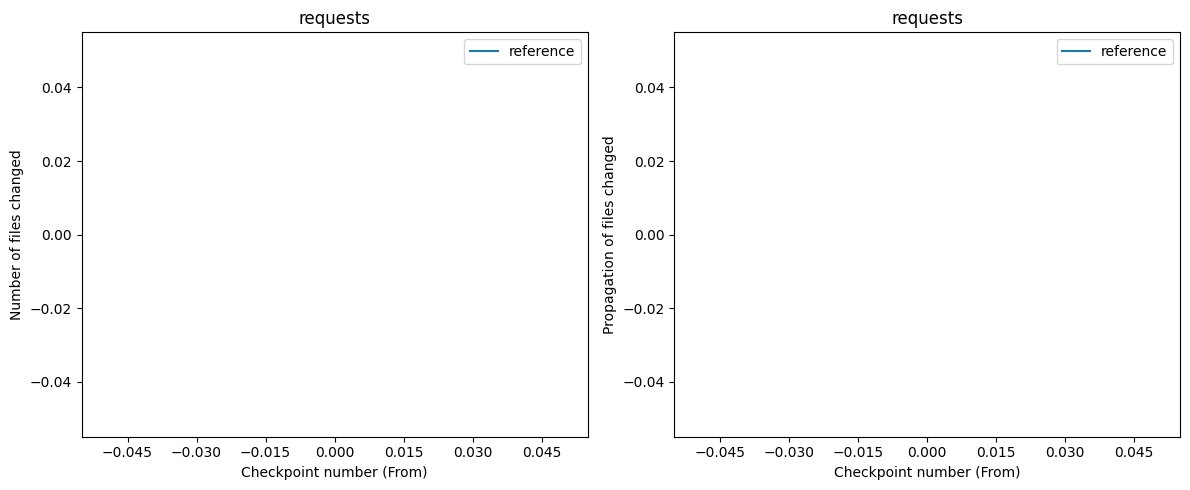

In [51]:
import os 
from metrics.change_coupling.overall_metrics import get_added_files, get_changed_files, get_deleted_files, get_all_modules, get_change_coupling

# data is in the form of [[c1, c2, ...], [c1, c2, ...]]
change_numbers = [] 
change_proportions = [] 

for mode_no, mode in enumerate(MODES): 
    # Obtain the checkpoint directories names of the problem
    # checkpoint_1, checkpoint_2, ... checkpoint_N
    checkpoint_dirs = []
    for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
        # only extract the top level iteration 
        checkpoint_dirs = dir 
        break 

    checkpoint_dirs = [x for x in checkpoint_dirs if x.startswith("checkpoint_")]
    checkpoint_dirs.sort() 

    cur_numbers = [] 
    cur_proportions = [] 
    # Walk through each checkpoint in pairs 
    for i in range(1, len(checkpoint_dirs)): 
        prev_impl_dir = dirs[mode_no] / checkpoint_dirs[i-1]
        impl_dir = dirs[mode_no] / checkpoint_dirs[i]

        # With respect to the prev impl and the current impl dir: determine the files that are added / changed / deleted 
        changed = get_changed_files(prev_impl_dir, impl_dir)
        total = get_all_modules(prev_impl_dir)
        print(f"{prev_impl_dir}->{impl_dir}: {get_changed_files(prev_impl_dir, impl_dir)}")

        cur_numbers.append(len(changed)) 
        cur_proportions.append(len(changed) / len(total))

    change_numbers.append(cur_numbers) 
    change_proportions.append(cur_proportions) 

    # print the change coupling metric 
    impl_dirs = [dirs[mode_no] / x for x in checkpoint_dirs]
    print(impl_dirs)
    print(get_change_coupling(impl_dirs))

# plot 
from matplotlib import pyplot as plt 
from matplotlib.ticker import MaxNLocator

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for i, entry in enumerate(change_numbers):
    x = range(1, len(entry) + 1) 
    y = entry
    ax1.plot(x, y, label=MODES[i])
ax1.set_xlabel("Checkpoint number (From)")
ax1.set_ylabel("Number of files changed")
ax1.set_title(PROBLEM)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
ax1.legend()

for i, entry in enumerate(change_proportions):
    x = range(1, len(entry) + 1)
    y = entry
    ax2.plot(x, y, label=MODES[i])
ax2.set_xlabel("Checkpoint number (From)")
ax2.set_ylabel("Propagation of files changed")
ax2.set_title(PROBLEM)
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
ax2.legend()

plt.tight_layout()
plt.show()

## Logical lines of code

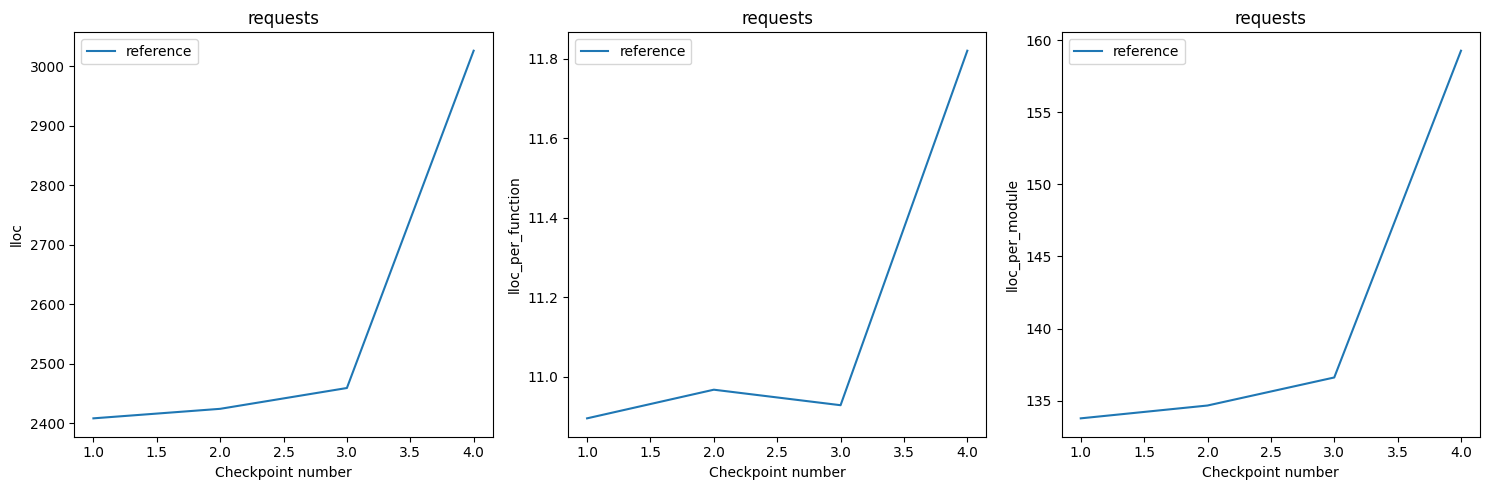

In [52]:
plot(metrics, ["lloc", "lloc_per_function", "lloc_per_module"])

## Functions with high CC / LOC

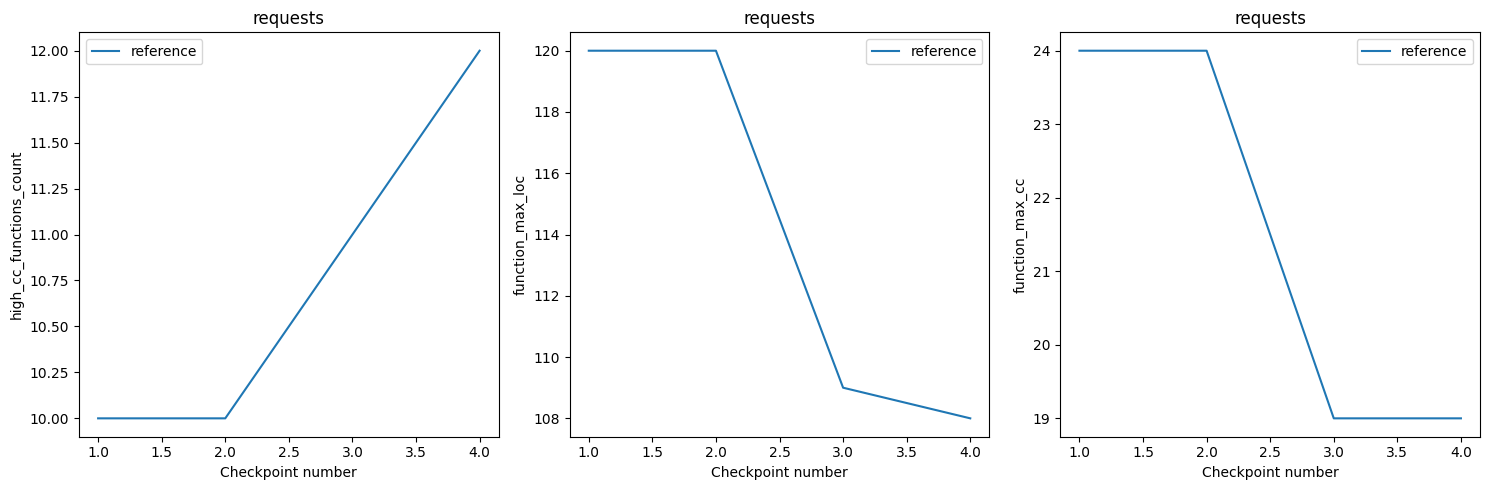

In [53]:
plot(metrics, ["high_cc_functions_count", "function_max_loc", "function_max_cc"])

## Maintainability index (Weighted)

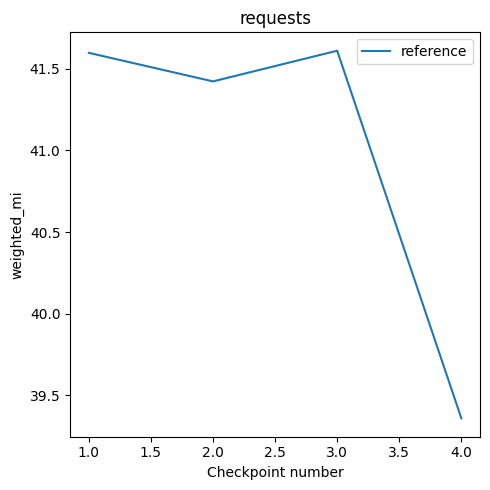

In [54]:
plot(metrics, ["weighted_mi"])

## Duplicated lines and tokens percentage

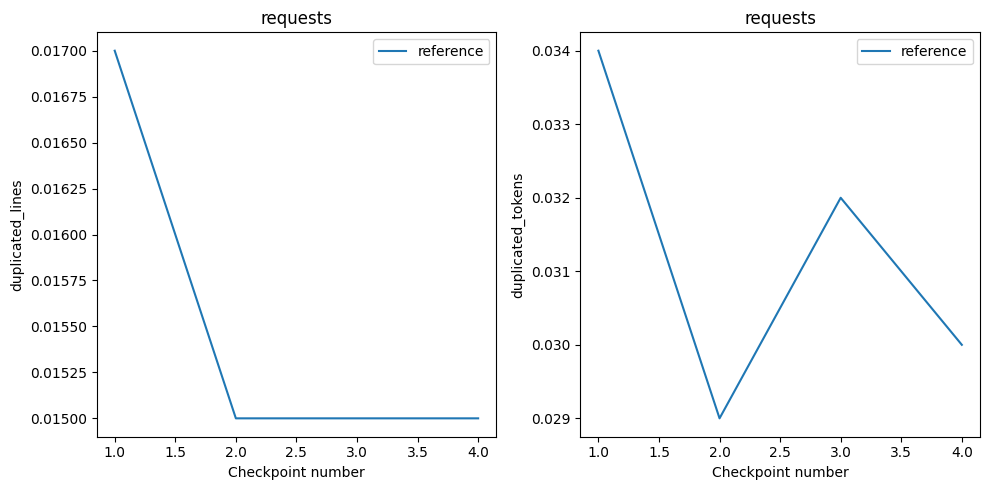

In [55]:
plot(metrics, ["duplicated_lines", "duplicated_tokens"])

## Whether graph has cycles

In [56]:
for i, entry in enumerate(metrics): 
    print(f"{MODES[i]}: {[x["has_cycles"] for x in entry]}")

reference: [False, False, False, True]


## NOPM per class

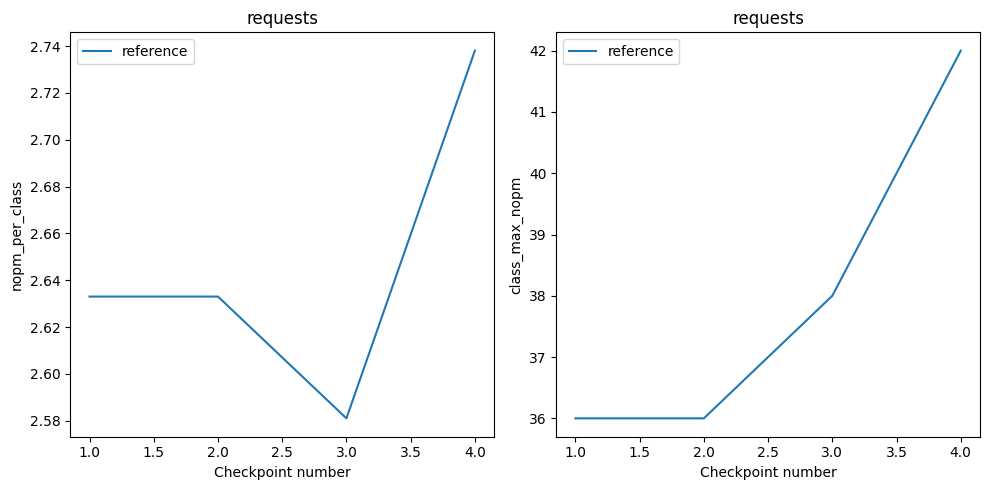

In [57]:
plot(metrics, ["nopm_per_class", "class_max_nopm"])

## Propagation cost, N and impact size

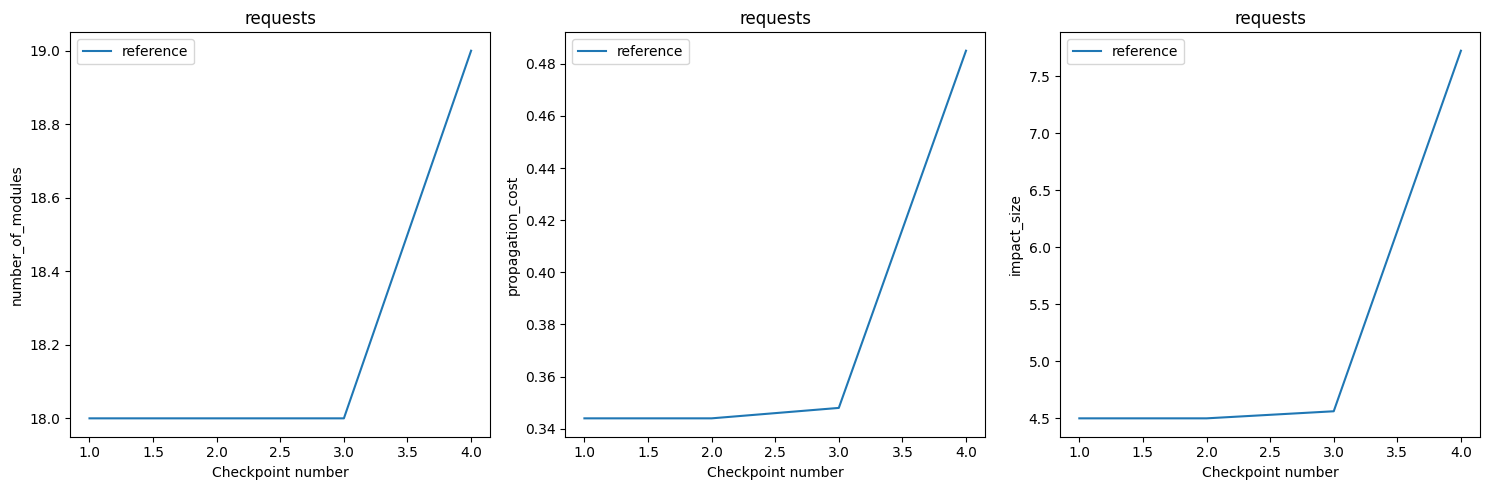

In [58]:
plot(metrics, ["number_of_modules", "propagation_cost", "impact_size"])

## Spider diagrams (test) 

## 

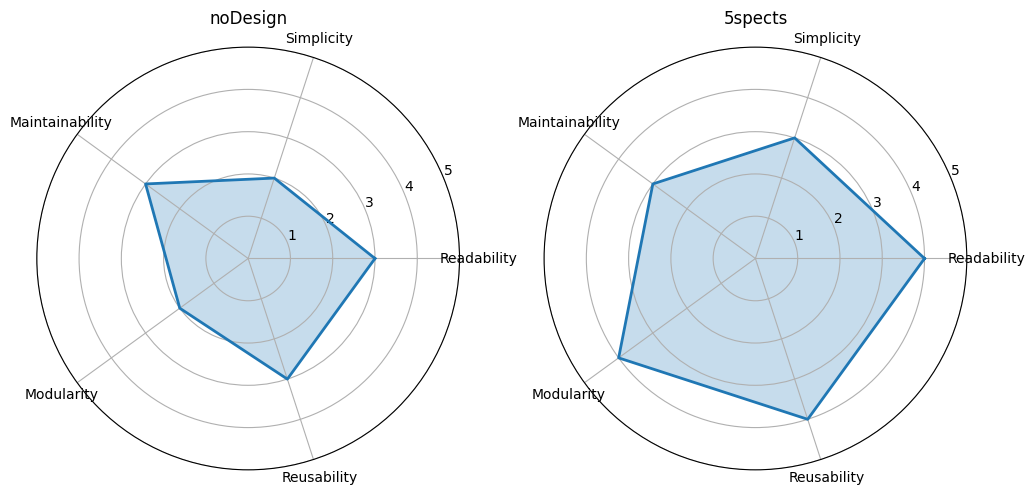

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Data
categories = ["Readability", "Simplicity", "Maintainability", "Modularity", "Reusability"]
values_noDesign = [3,2,3,2,3]
values_5aspects = [4,3,3,4,4]

# Number of variables
N = len(categories)

# Compute angle for each axis
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # complete the loop

# Values also need to loop back to the first point
# (Append the first value to the end) 
values_noDesign += values_noDesign[:1]
values_5aspects += values_5aspects[:1]

# Create the plot
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12, 6), subplot_kw=dict(polar=True))

# Draw the outline and fill
ax1.plot(angles, values_noDesign, linewidth=2, linestyle='solid')
ax1.fill(angles, values_noDesign, alpha=0.25)

# Set category labels
ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(categories)

# Optional: set y-axis limits and gridlines
ax1.set_ylim(0, 5)
ax1.set_yticks([1, 2, 3, 4, 5])

ax1.set_title("noDesign")

# Draw the outline and fill
ax2.plot(angles, values_5aspects, linewidth=2, linestyle='solid')
ax2.fill(angles, values_5aspects, alpha=0.25)

# Set category labels
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories)

# Optional: set y-axis limits and gridlines
ax2.set_ylim(0, 5)
ax2.set_yticks([1, 2, 3, 4, 5])

ax2.set_title("5spects")

plt.show()